In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

In [2]:
df = pd.read_csv("student_decision_tree.csv")

In [3]:
df

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
0,101,2,60,55,50,65,0
1,102,3,65,58,55,70,0
2,103,4,70,60,60,72,0
3,104,5,75,68,65,75,1
4,105,6,80,72,70,80,1
5,106,7,85,78,75,82,1
6,107,8,90,82,80,85,1
7,108,2,55,50,48,60,0
8,109,3,68,62,58,68,0
9,110,4,72,65,63,74,1


In [4]:
df.head()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
0,101,2,60,55,50,65,0
1,102,3,65,58,55,70,0
2,103,4,70,60,60,72,0
3,104,5,75,68,65,75,1
4,105,6,80,72,70,80,1


In [5]:
df.head()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
0,101,2,60,55,50,65,0
1,102,3,65,58,55,70,0
2,103,4,70,60,60,72,0
3,104,5,75,68,65,75,1
4,105,6,80,72,70,80,1


In [6]:
df.tail()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
25,126,6,83,76,74,82,1
26,127,7,89,81,79,86,1
27,128,8,94,88,86,91,1
28,129,2,59,54,50,63,0
29,130,5,79,73,69,77,1


In [7]:
df.shape

(30, 7)

In [8]:
df.columns

Index(['Student_ID', 'Study_Hours', 'Attendance', 'Assignments',
       'Previous_Marks', 'Discipline', 'Pass'],
      dtype='str')

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   Student_ID      30 non-null     int64
 1   Study_Hours     30 non-null     int64
 2   Attendance      30 non-null     int64
 3   Assignments     30 non-null     int64
 4   Previous_Marks  30 non-null     int64
 5   Discipline      30 non-null     int64
 6   Pass            30 non-null     int64
dtypes: int64(7)
memory usage: 1.8 KB


In [10]:
df.describe()

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
count,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000,30.000000
mean,115.500000,4.466667,72.500000,65.666667,63.000000,73.166667,0.566667
std,8.803408,2.129163,12.851271,12.507469,12.752282,10.248914,0.504007
min,101.000000,1.000000,48.000000,40.000000,38.000000,50.000000,0.000000
25%,108.250000,3.000000,62.250000,55.500000,52.500000,66.500000,0.000000
50%,115.500000,4.500000,73.500000,66.500000,64.000000,74.500000,1.000000
75%,122.750000,6.000000,81.750000,74.750000,71.750000,80.000000,1.000000
max,130.000000,8.000000,94.000000,88.000000,86.000000,91.000000,1.000000


In [11]:
df.isnull().sum()

Student_ID        0
Study_Hours       0
Attendance        0
Assignments       0
Previous_Marks    0
Discipline        0
Pass              0
dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

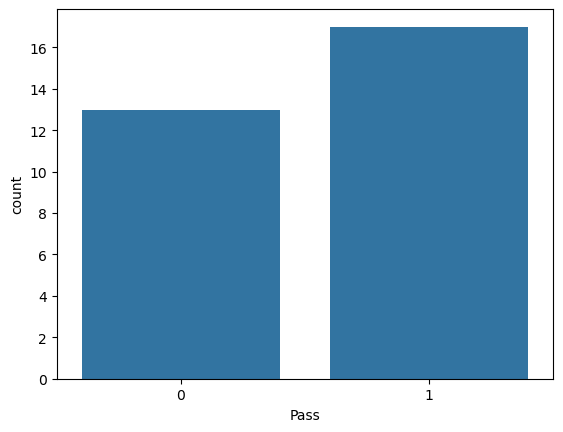

In [13]:
sns.countplot(x="Pass", data=df)
plt.show()

In [14]:
df.corr(numeric_only=True)

,Student_ID,Study_Hours,Attendance,Assignments,Previous_Marks,Discipline,Pass
Student_ID,1.000000,0.088305,0.107440,0.126521,0.121328,0.093062,0.167091
Study_Hours,0.088305,1.000000,0.988014,0.981074,0.988064,0.972884,0.837611
Attendance,0.107440,0.988014,1.000000,0.996274,0.997768,0.989492,0.849142
Assignments,0.126521,0.981074,0.996274,1.000000,0.997305,0.989836,0.846044
Previous_Marks,0.121328,0.988064,0.997768,0.997305,1.000000,0.990973,0.842320
Discipline,0.093062,0.972884,0.989492,0.989836,0.990973,1.000000,0.822206
Pass,0.167091,0.837611,0.849142,0.846044,0.842320,0.822206,1.000000


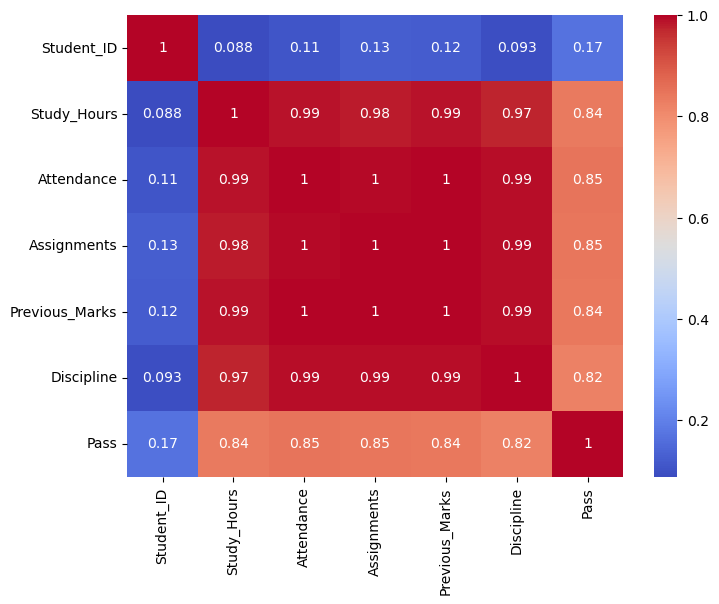

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.show()

In [17]:
X = df.drop(["Student_ID","Pass"], axis=1)

In [18]:
y = df["Pass"]

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [20]:
X_train.shape

(24, 5)

In [21]:
X_test.shape

(6, 5)

In [22]:
model = DecisionTreeClassifier(random_state=42)

In [23]:
model.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [24]:
y_pred = model.predict(X_test)

In [25]:
print(y_pred)

[1 0 0 1 0 1]


In [28]:
y_test

27    1
15    0
23    1
17    1
8     0
9     1
Name: Pass, dtype: int64

In [29]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.8333333333333334


In [30]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[2 0]
 [1 3]]


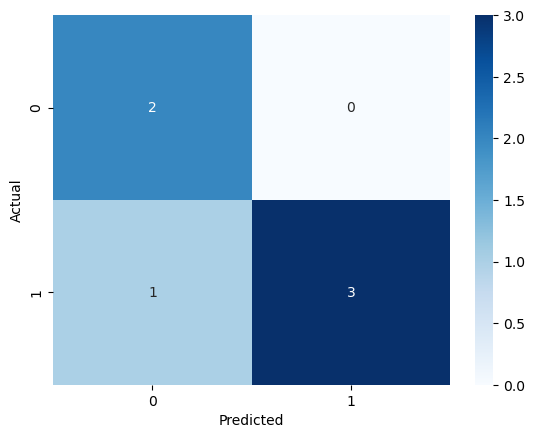

In [31]:
sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [32]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.67      1.00      0.80         2
           1       1.00      0.75      0.86         4

    accuracy                           0.83         6
   macro avg       0.83      0.88      0.83         6
weighted avg       0.89      0.83      0.84         6



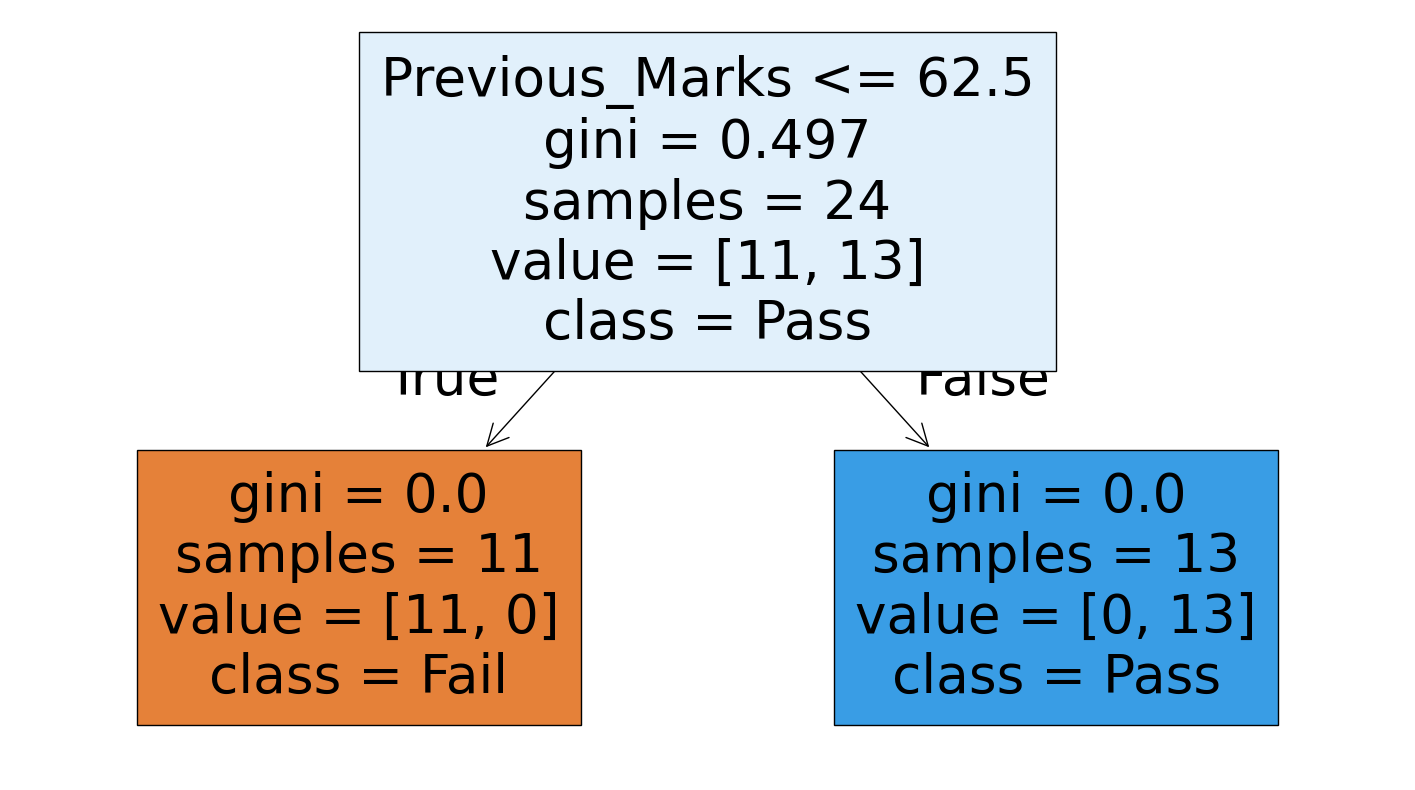

In [33]:
plt.figure(figsize=(18,10))

plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Fail","Pass"],
    filled=True
)

plt.show()

In [34]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
3,Previous_Marks,1.0
0,Study_Hours,0.0
1,Attendance,0.0
2,Assignments,0.0
4,Discipline,0.0


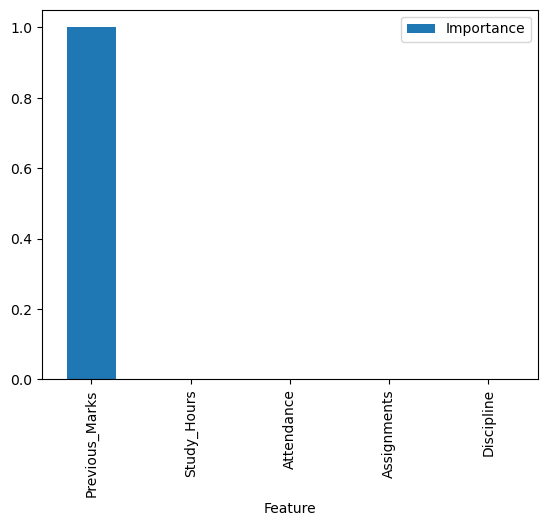

In [35]:
importance.sort_values(
    by="Importance",
    ascending=False
).plot(
    x="Feature",
    y="Importance",
    kind="bar"
)

plt.show()

In [36]:
new_student = [[6,82,75,72,80]]

In [37]:
prediction = model.predict(new_student)

print(prediction)

[1]


C:\Users\Dictator\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [38]:
new_students = [
    [2,55,48,45,60],
    [6,82,75,72,80],
    [8,95,88,86,92]
]

pred = model.predict(new_students)

print(pred)

[0 1 1]


C:\Users\Dictator\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [39]:
import joblib

joblib.dump(model, "decision_tree_model.pkl")

['decision_tree_model.pkl']

In [ ]:
# model = joblib.load("decision_tree_model.pkl")